---
title: >-
  25 Years of Interactive Scientific Computing: From IPython and Jupyter to
  Open Source IDE-Native Notebooks
description: >-
  An executable history of interactive scientific computing, tracing the
  evolution from IPython through Project Jupyter to contemporary open-source
  IDE-native notebook environments and AI-assisted scientific workflows.
authors:
  - name: Rodrigo Silva Ferreira
    email: rodrigosf672@gmail.com
    orcid: 0009-0006-4991-5051
    corresponding: true
    affiliations:
      - Independent Researcher, Pittsburgh, PA, USA
abstract: |
  Interactive computing has reshaped how scientists explore data, develop methods, and communicate results. This paper traces twenty-five years of that transformation, from the 2001 release of IPython through the formation of Project Jupyter to the contemporary movement that embeds notebooks inside full software-development environments. We argue that this history is best understood not as the story of a file format or a user interface, but as the steady reduction of friction between four activities that were once pursued with separate tools: exploratory analysis, software engineering, collaboration, and reproducible publication. Read this way, each generation inherited the strengths of the previous one while absorbing a capability that had previously lived elsewhere. We further argue that openness (*e.g.,* of source code, of standards such as the Jupyter messaging protocol and the nbformat document schema, of community governance, and of the executable publication itself) has been the decisive enabler at every stage. After surveying the pre-Jupyter landscape and the scientific Python ecosystem that grew alongside these tools, we examine the well-documented limitations of traditional notebooks, the engineering practices that IDE-native notebooks restore, and the opportunities and risks introduced by large language models. The paper is itself an executable Jupyter notebook: every figure and quantitative claim is produced by the code it contains.
keywords:
  - interactive computing
  - Jupyter
  - IPython
  - reproducible research
  - scientific Python
  - literate programming
  - open science
  - notebooks
---


In [1]:
# --- Reproducible setup -----------------------------------------------------
# This single cell configures the environment, fixes the random seed, defines a
# restrained publication style, and provides the helper functions that draw the
# schematic figures used throughout the paper. Scientific demonstrations are
# kept inline, at the point in the narrative where they are discussed.
import os, sys, platform, hashlib
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D

%matplotlib inline

os.makedirs("figures", exist_ok=True)
SEED = 20260619
rng = np.random.default_rng(SEED)        # one generator, threaded through the paper

# A color-blind-aware qualitative palette (after Paul Tol's "muted" scheme).
TOL = ["#332288", "#117733", "#CC6677", "#88CCEE", "#DDCC77",
       "#AA4499", "#44AA99", "#882255"]
INK, MUTED = "#1b1b1b", "#6b6b6b"

def set_style():
    mpl.rcParams.update({
        "figure.dpi": 120, "savefig.dpi": 200, "savefig.bbox": "tight",
        "figure.facecolor": "white", "axes.facecolor": "white",
        "font.family": "serif",
        "font.serif": ["DejaVu Serif", "Times New Roman", "Georgia"],
        "mathtext.fontset": "dejavuserif",
        "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
        "axes.labelsize": 11, "axes.edgecolor": "#444444", "axes.linewidth": 0.9,
        "axes.grid": True, "grid.color": "#d8d8d8", "grid.linewidth": 0.7,
        "xtick.labelsize": 10, "ytick.labelsize": 10,
        "legend.fontsize": 9.5, "legend.frameon": False,
        "axes.spines.top": False, "axes.spines.right": False,
    })
set_style()

def _save(fig, name):
    fig.savefig(f"figures/{name}.png")
    fig.savefig(f"figures/{name}.pdf")   # vector copy for typesetting

print(f"Python {platform.python_version()} | NumPy {np.__version__} | "
      f"Matplotlib {mpl.__version__} | seed {SEED}")

Python 3.14.6 | NumPy 2.4.6 | Matplotlib 3.11.0 | seed 20260619


In [2]:
# --- Figure helpers (schematic diagrams) ------------------------------------
from figure_helpers import *
print("figure helpers imported")

figure helpers defined: ['fig_architecture', 'fig_capabilities', 'fig_ecosystem', 'fig_repro_bars', 'fig_timeline']


## Introduction
Computation has become a third mode of scientific inquiry, standing beside theory and experiment rather than merely serving them. Climate projections, genome assemblies, gravitational-wave detections, and the calibration of language models are all, at bottom, programs run over data. As the centre of gravity of research has shifted toward software, the tools used to write that software have stopped being incidental laboratory equipment and have become part of the scientific method itself. How a result is computed (and whether that computation can be inspected, rerun, and trusted by others) is now inseparable from whether the result is believed.

This shift has placed *reproducibility* at the heart of methodological debate. @donoho2010invitation framed reproducible computational research as the discipline of publishing, alongside each figure and table, the complete software environment that generated it, reviving a tradition that @claerbout1992electronic and @buckheit1995wavelab had pioneered in geophysics and signal processing. A decade later, an interdisciplinary consensus statement in *Science* called for code and data to be treated as first-class research artifacts [@stodden2016enhancing], and community guides distilled the accumulated experience into actionable practice [@wilson2014best; @wilson2017good]. The recurring lesson is that scientific software is rarely written the way production software is. It grows through *exploratory programming*: a tight loop of hypothesis, quick implementation, visualization, and revision, in which the program and the scientist's understanding co-evolve.

Interactivity changed research because it changed the unit of iteration. When a computation must be edited, recompiled, and resubmitted as a batch job, the cost of a single question is measured in minutes or hours, and the scientist learns to ask few, large questions. When the same computation answers in the time it takes to press a key, the cost of a question falls toward zero, and a different epistemic style becomes possible: a hypothesis is posed, tested against data, visualized, and revised dozens of times in an afternoon. The interactive loop does not merely speed up analysis; it widens the space of analyses a researcher will attempt, surfacing patterns and mistakes that a batch workflow would never have prompted anyone to look for. This is why cheap interactivity, far from being a mere convenience, reorganized the practice of computational science around exploration, and why the tools that host that exploration came to matter so much.

Exploration and communication, however, pull in opposite directions. Exploration rewards speed, mutable state, and disposable code; communication rewards clarity, structure, and permanence. @knuth1984literate's vision of *literate programming* (*i.e.,* a program written as a human narrative, with source code woven into prose) was an early attempt to reconcile the two, prioritizing explanation to people over instruction to machines. Interactive computing environments inherited this tension and, over twenty-five years, progressively dissolved it. The thesis of this paper is that the history of interactive scientific computing is the history of *reducing friction* among four activities (*i.e.,* exploration, engineering, collaboration, and reproducible publication) and that *openness* in its several forms has been the mechanism by which that friction was removed. Figure 1 previews the milestones along the way; the sections that follow trace them in turn.

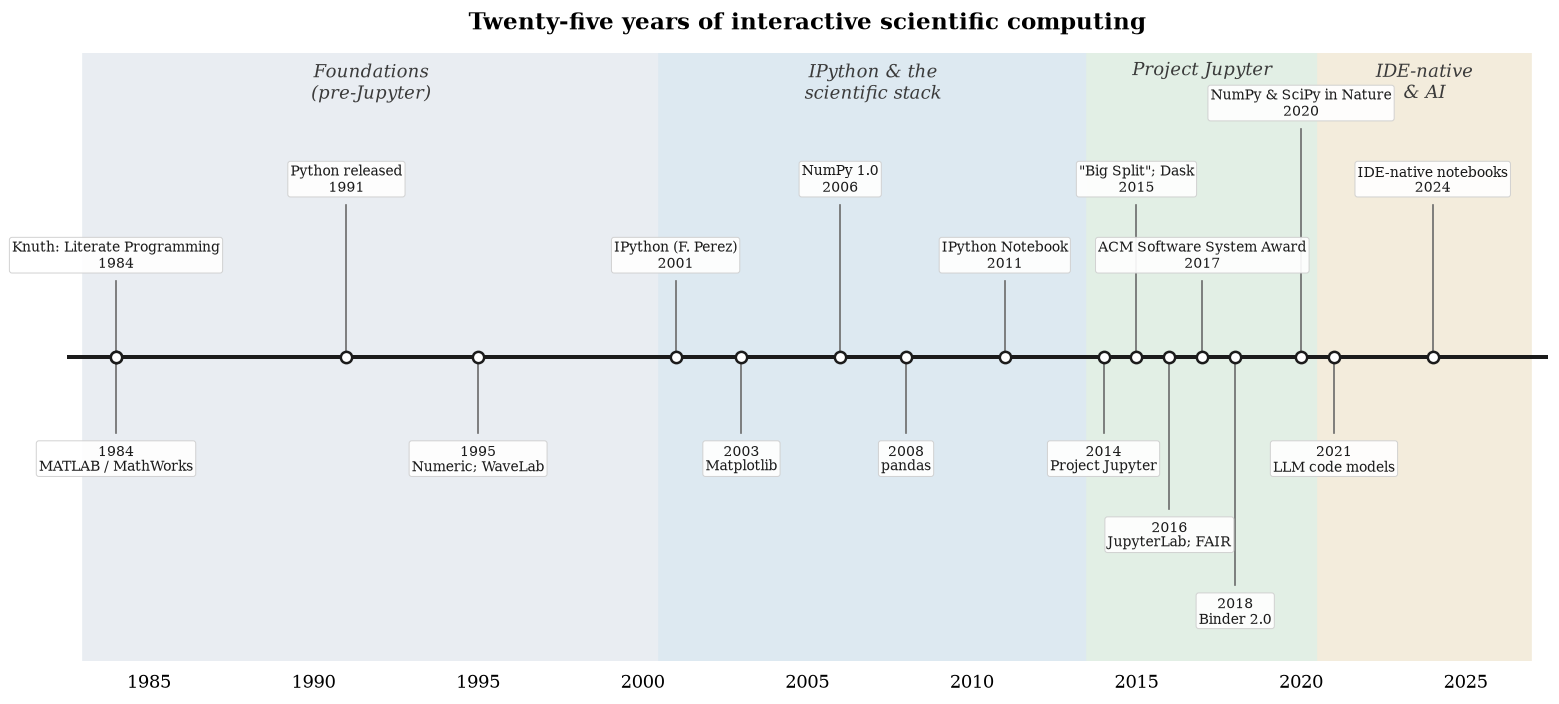

In [3]:
fig_timeline()

**Figure 1.** A timeline of interactive scientific computing, organized into four overlapping eras. Each era inherits the capabilities of the previous one while integrating a concern (e.g., rich output, language independence, reproducible environments, software engineering) that had previously required separate tools. Dates are drawn from primary sources cited throughout the paper.

## Before Jupyter: REPLs, computer algebra, and literate programming
Interactivity in computing is older than the personal computer. Its lineage runs back to Lisp, whose read–eval–print loop (REPL) let a programmer type an expression and see its value immediately; McCarthy's language of 1958–1960 and the interactive Lisp systems built on it established a style of conversation with a running process that every later environment would imitate. For decades, however, the dominant mode of scientific computing was the opposite of conversational. Programs were compiled, submitted as batch jobs, and inspected only after they finished (a workflow well matched to expensive, shared mainframes but hostile to the rapid, speculative iteration that data analysis demands).

The first tools to make scientific computing genuinely interactive were, tellingly, commercial. MATLAB began in the late 1970s when Cleve Moler wrote a Fortran "matrix laboratory" so that students could call the LINPACK and EISPACK linear-algebra libraries without writing Fortran themselves; he used it during a 1979 sabbatical at Stanford, and in 1984 he and Jack Little founded MathWorks to commercialize it [@moler2020history]. Computer-algebra systems followed a parallel path: Maple was conceived at the University of Waterloo in late 1980 as a lower-cost alternative to running Macsyma, and Mathematica was launched by Wolfram Research on 23 June 1988, introducing a *notebook* interface in which cells of evaluatable input and formatted output were interleaved on a single page. The notebook metaphor that Jupyter would later make ubiquitous was thus already two decades old. Statistical computing, meanwhile, was transformed by the S language developed at Bell Labs by Becker, Chambers, and colleagues [@becker1984s], whose open-source reimplementation as R by [@ihaka1996r] would become the lingua franca of statistics.

These systems were powerful, but each was, in a precise sense, *closed*. Most were proprietary; each was wedded to a single language and a single vendor; and the documents they produced (where documents existed at all) were rarely separable from the application that created them. In parallel, a quieter intellectual movement was preparing the ground for something more open. [@knuth1984literate; @knuth1992literate] argued in *literate programming* that a program should be written for human readers, as an essay whose narrative order need not match the compiler's, with code extracted ("tangled") and documentation typeset ("woven") from one source; his WEB system, built to document the TeX typesetting program, was the proof of concept. At nearly the same moment, @claerbout1992electronic coined the term *reproducible research* for the practice of bundling, with a publication, the electronic documents and code needed to regenerate every figure, and @buckheit1995wavelab popularized the idea in the WaveLab toolbox, distributing the exact code that produced each plot in their wavelet papers. Literate programming supplied the *form* (*i.e.,* narrative and code as one document) and reproducible research supplied the *purpose*. Interactive scientific computing in the Python era would inherit both, and add what the earlier systems lacked: an open-source implementation, an open document standard, and a community free to extend them.

## IPython: an open, interactive shell for scientific Python
In 2001, Fernando Pérez was a graduate student in physics at the University of Colorado, Boulder, who wanted for Python the conveniences he admired in Mathematica and Maple: numbered input and output prompts, easy access to previous results, on-the-spot help and introspection, and a configurable, comfortable interactive session. What he wrote, as he later described it, was a 259-line "thesis procrastination project" (*i.e.,* a script loaded at startup) that gave the standard Python prompt a memory and a personality. Released as IPython 0.0.1 in December 2001 [@ipython2001firstrelease], it soon merged ideas and code from two kindred efforts, Janko Hauser's IPP and Nathaniel Gray's LazyPython, combining a well-organized architecture with terse interactive syntax and rich, colored tracebacks (IPython development team; [@perez2007ipython]).

The design choices that followed proved durable. IPython introduced *magic commands* (e.g., line magics such as `%timeit` and `%matplotlib`, and cell magics prefixed with `%%`) that extend the language of the session without polluting the Python namespace. It made *introspection* immediate: appending `?` to any object prints its documentation and signature, and `??` shows its source. It cached inputs and outputs so that prior results remained addressable, and it offered tab completion and a configuration system that let users shape their environment. Crucially, and unlike the commercial systems that inspired it, IPython was open source from its first day, developed in the open by a widening circle of contributors and eventually sustained by foundation grants (*e.g.,* an Alfred P. Sloan Foundation award in 2013, followed in 2015 by roughly six million dollars from the Helmsley, Moore, and Sloan foundations to expand the project) [@perez2007ipython; @perkel2018jupyter]. The small convenience of a better prompt had become community infrastructure.

The demonstration below uses one of those magics. The kernel executing this very notebook is IPython, so `%timeit` is available to us as we read; it quantifies the single most important habit in scientific Python (*i.e.,* replacing explicit Python loops with vectorized array operations), a point we return to in Section 5.

In [4]:
import numpy as np

x = rng.standard_normal(1_000_000)

# %timeit is an IPython "magic": it runs a statement many times and reports the best.
t_loop = %timeit -o -n 3 -r 3 [v * v for v in x]      # pure-Python loop
t_vec  = %timeit -o -n 50 -r 5 x * x                   # vectorized (NumPy)

print(f"\nVectorization speed-up on this machine: "
      f"{t_loop.best / t_vec.best:,.0f}x")

35 ms ± 73.2 μs per loop (mean ± std. dev. of 3 runs, 3 loops each)
128 μs ± 2.58 μs per loop (mean ± std. dev. of 5 runs, 50 loops each)

Vectorization speed-up on this machine: 283x


The two lines compute the same thing (*i.e.,* the element-wise square of a million numbers) but the vectorized form runs hundreds of times faster. Being able to *measure* that gap in a single keystroke, mid-thought, is the essence of what IPython added: not a new language, but a new tightness in the loop between writing code and understanding its behaviour.

## Project Jupyter: from a shell to an open protocol
IPython's most consequential idea was architectural rather than cosmetic. To support a graphical Qt console (2011) and then a browser-based notebook (first shipped in IPython 0.12 in December 2011, drawing heavy inspiration from William Stein's pioneering Sage Notebook), the project separated the *frontend* that a user interacts with from the *kernel* that executes code, with the two communicating over a well-specified network protocol. Once execution lived behind a protocol rather than inside the shell, the language of the kernel became an implementation detail. A frontend that could talk to a Python kernel could talk to any kernel.

This realization motivated "the Big Split." IPython 3.0, released in February 2015, was the last release to bundle the language-agnostic notebook with the Python-specific shell; IPython 4.0, on 11 August 2015, moved the frontend, the notebook document format, and the protocol into a new, language-neutral umbrella: Project Jupyter, whose name honours its three founding languages (*i.e.,* Julia, Python, and R [@ihaka1996r]) and alludes to Galileo's notebooks recording the moons of Jupiter. This transition, formalized in a defining 2016 paper authored by core architects Thomas Kluyver, Min Ragan-Kelley, Fernando Pérez, Brian Granger, Matthias Bussonnier, Damian Avila, Kyle Kelley, Carol Willing, Jason Grout, Sylvain Corlay, and others [@kluyver2016jupyter], was not a rebranding but a deliberate act of *opening*: it declared that the value of the notebook lay in a set of open standards that no single language community owned.

Figure 2 sketches the resulting architecture. A frontend and a kernel communicate over a ZeroMQ-based messaging protocol [@jupyter-messaging] carried on five sockets (*i.e.,* Shell, IOPub, stdin, Control, and Heartbeat), each with a defined role (Jupyter development team, *Messaging*). The Shell channel carries `execute_request` messages and their replies; the IOPub channel broadcasts side effects (*e.g.,* standard output, rich `display_data`, and `execute_result`) to every connected client; stdin handles input prompts; Control carries high-priority interrupt and shutdown messages; and Heartbeat confirms liveness. Every message is signed with an HMAC digest and serialized, by default, as JSON, so that any process implementing the protocol can serve as a kernel.

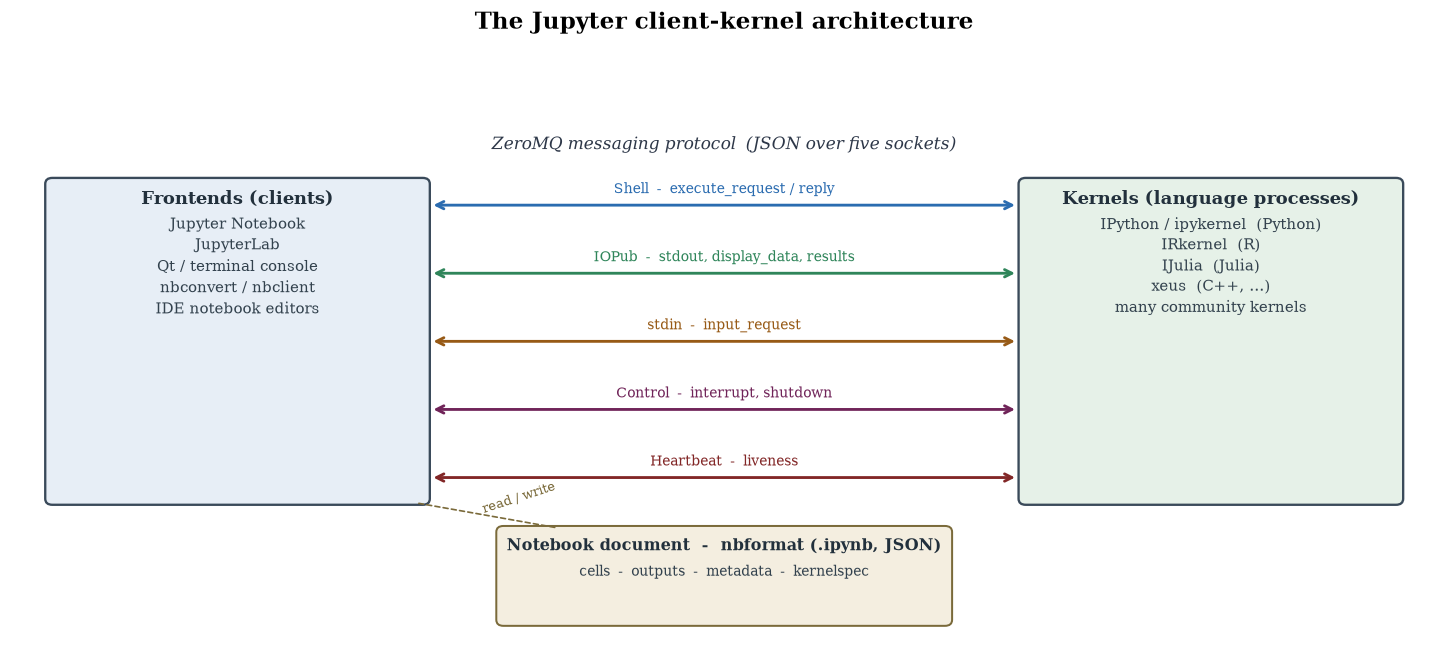

In [5]:
fig_architecture()

**Figure 2.** The Jupyter client–kernel architecture. Decoupling the user-facing frontend from the language kernel behind an open, signed messaging protocol is what makes Jupyter language-agnostic: a *kernelspec* registers any conforming interpreter, and dozens of community kernels now exist. The notebook document (`nbformat`) is an independent JSON artifact that frontends read and write.

The flow of a single execution is worth making concrete, because it explains both the power and the hazards of notebooks discussed later. Figure 3 shows the message exchange when a user runs one cell.

```text
sequenceDiagram
    autonumber
    participant F as Frontend
    participant S as Shell channel
    participant K as Kernel
    participant IO as IOPub channel
    F->>S: execute_request (source, msg_id)
    S->>K: deliver request
    K-->>IO: status = busy
    K-->>IO: execute_input (echo source, count = n)
    K-->>IO: stream / display_data / execute_result
    K-->>S: execute_reply (status = ok, count = n)
    K-->>IO: status = idle
```

**Figure 3.** The messaging sequence for executing one cell. The kernel maintains an execution counter `n` and a persistent namespace; the frontend records each cell's outputs and that counter in the notebook document. Because the counter reflects the *order of execution*, not the order of cells on the page, a saved notebook can encode a history that no top-to-bottom run would reproduce (*i.e.,* the seed of the reproducibility problems examined in Section 7.

Two open standards complete the picture. The *kernelspec* mechanism (*i.e.,* a small `kernel.json` file in a known location) lets any language that speaks the protocol be installed as a kernel, which is why Jupyter today drives Python, R, Julia, C++, and many other languages from one interface. The `nbformat` schema defines the notebook itself as a JSON document with top-level `cells`, `metadata`, and version fields, where each cell is `code`, `markdown`, or `raw` and code cells carry their outputs inline (Jupyter development team, *nbformat*; Kluyver et al., 2016). Because the format is open and text-based, notebooks can be generated, transformed, executed, and rendered by an entire ecosystem of tools rather than a single application. On this foundation grew JupyterLab (unveiled in alpha at SciPy 2016 and released as 1.0 in June 2019) and JupyterHub for multi-user deployments, work recognized by the 2017 ACM Software System Award, presented in 2018 (Granger and Pérez, 2021). The recurring pattern is openness compounding: an open protocol enabled an open document format, which enabled an open ecosystem.

## The scientific Python ecosystem, accelerated
Jupyter did not create the scientific Python ecosystem, but it gave that ecosystem an interactive interface of unprecedented reach, and the two grew together. The stack is layered (Figure 4). At its base sits CPython with compiled extensions; above that, NumPy provides the n-dimensional array, its universal functions, and the broadcasting rules that let array expressions stand in for explicit loops [@harris2020array]. NumPy traces its lineage to Numeric (Jim Hugunin, 1995) and numarray, which Travis Oliphant, Charles R. Harris, Nathaniel J. Smith, and others unified and grew into NumPy, released as 1.0 in 2006. On the array core rest the libraries most analyses touch directly: SciPy for numerical algorithms (driven by Pauli Virtanen, Ralf Gommers, Stefan van der Walt, and a massive community) [@virtanen2020scipy], pandas for labeled, heterogeneous, tabular and time-series data [@mckinney2010data], Matplotlib for publication-quality graphics [@hunter2007matplotlib], and SymPy for symbolic mathematics [@meurer2017sympy]. Domain libraries (*e.g.,* scikit-learn for machine learning [@pedregosa2011scikit], xarray for labeled N-dimensional data [@hoyer2017xarray], and others) build on these, while Dask extends the same array and dataframe interfaces to larger-than-memory and parallel computation [@rocklin2015dask].

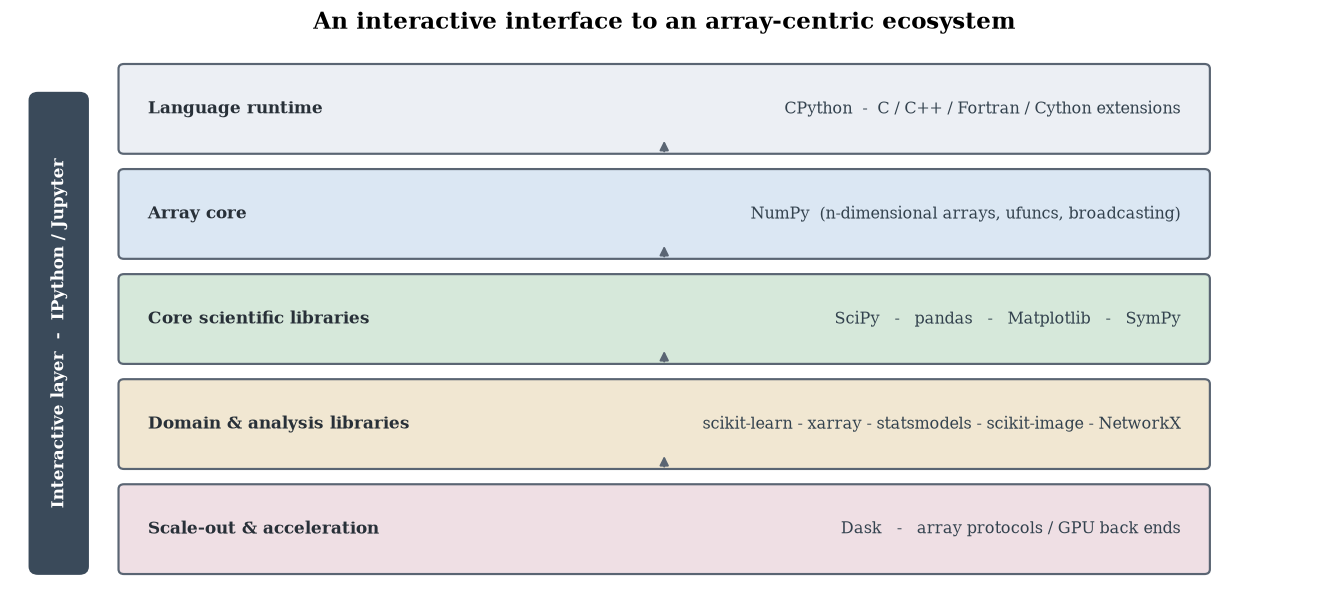

In [6]:
fig_ecosystem()

**Figure 4.** The array-centric scientific Python stack. A shared array substrate (NumPy) lets independently developed libraries interoperate, and a common interactive layer (IPython/Jupyter) lets a researcher move fluidly among them. The ecosystem's coherence is a direct dividend of open, shared interfaces.

The remainder of this section is a short tour of that stack in action, with each computation chosen to make a point rather than to decorate the page. We begin with the idiom that defines numerical Python, vectorization (already previewed in Section 3, now measured across problem sizes).

speed-ups by size: ['60x', '57x', '250x']


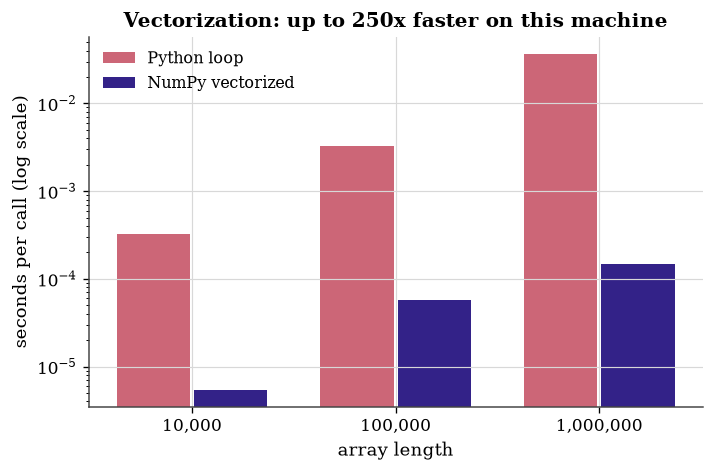

In [7]:
import timeit
import numpy as np
import matplotlib.pyplot as plt

sizes = [10_000, 100_000, 1_000_000]
loop_t, vec_t = [], []
for n in sizes:
    a = rng.standard_normal(n)
    loop_t.append(timeit.timeit(lambda: [v * v for v in a], number=3) / 3)
    vec_t.append(timeit.timeit(lambda: a * a, number=50) / 50)

speedup = [l / v for l, v in zip(loop_t, vec_t)]
fig, ax = plt.subplots(figsize=(6.6, 4.0))
idx = np.arange(len(sizes))
ax.bar(idx - 0.19, loop_t, 0.36, color=TOL[2], label="Python loop")
ax.bar(idx + 0.19, vec_t, 0.36, color=TOL[0], label="NumPy vectorized")
ax.set_yscale("log"); ax.set_xticks(idx); ax.set_xticklabels([f"{n:,}" for n in sizes])
ax.set_xlabel("array length"); ax.set_ylabel("seconds per call (log scale)"); ax.legend()
ax.set_title(f"Vectorization: up to {max(speedup):.0f}x faster on this machine")
_save(fig, "demo_numpy")
print("speed-ups by size:", [f"{s:.0f}x" for s in speedup])

**Figure 5.** Element-wise squaring via an explicit Python loop versus a NumPy array expression, timed across three problem sizes (note the logarithmic axis). The gap widens with size: pushing the loop into compiled, vectorized code is the foundation on which every higher library is built.

Real data is rarely an anonymous array; it carries labels, units, and time. pandas exists to keep those labels attached through every operation. The next cell synthesizes an hourly temperature record with a diurnal cycle and noise, then uses a `DatetimeIndex` to resample to daily means and to compute a rolling trend (operations that would be error-prone with bare arrays but are one line each with labeled data.

hourly points: 720 | daily means: 30 | overall mean: 15.66 degC


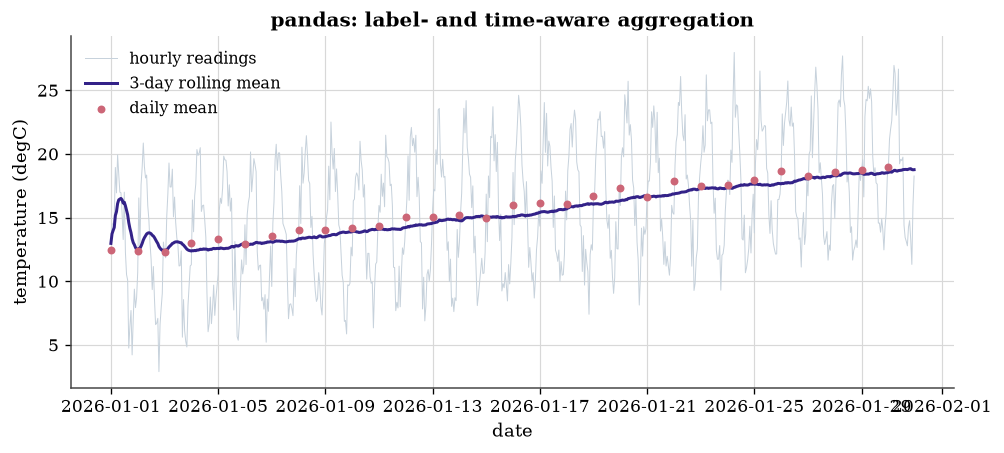

In [8]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

hours = pd.date_range("2026-01-01", periods=24 * 30, freq="h")
t = np.arange(len(hours))
signal = (12 + 6 * np.sin(2 * np.pi * t / 24)           # diurnal cycle
          + 0.01 * t                                     # slow warming trend
          + rng.normal(0, 1.5, len(hours)))              # measurement noise
ts = pd.Series(signal, index=hours, name="temperature_C")

daily = ts.resample("D").mean()                          # label-aware aggregation
trend = ts.rolling("3D").mean()                          # 3-day rolling mean

fig, ax = plt.subplots(figsize=(9.5, 3.8))
ax.plot(ts.index, ts.values, color="#c7d2dc", lw=0.6, label="hourly readings")
ax.plot(trend.index, trend.values, color=TOL[0], lw=1.8, label="3-day rolling mean")
ax.scatter(daily.index, daily.values, color=TOL[2], s=14, zorder=5, label="daily mean")
ax.set_xlabel("date"); ax.set_ylabel("temperature (degC)"); ax.legend(loc="upper left")
ax.set_title("pandas: label- and time-aware aggregation")
_save(fig, "demo_pandas")
print(f"hourly points: {len(ts)} | daily means: {len(daily)} | "
      f"overall mean: {ts.mean():.2f} degC")

recovered dominant frequencies: 7.0 Hz and 23.0 Hz


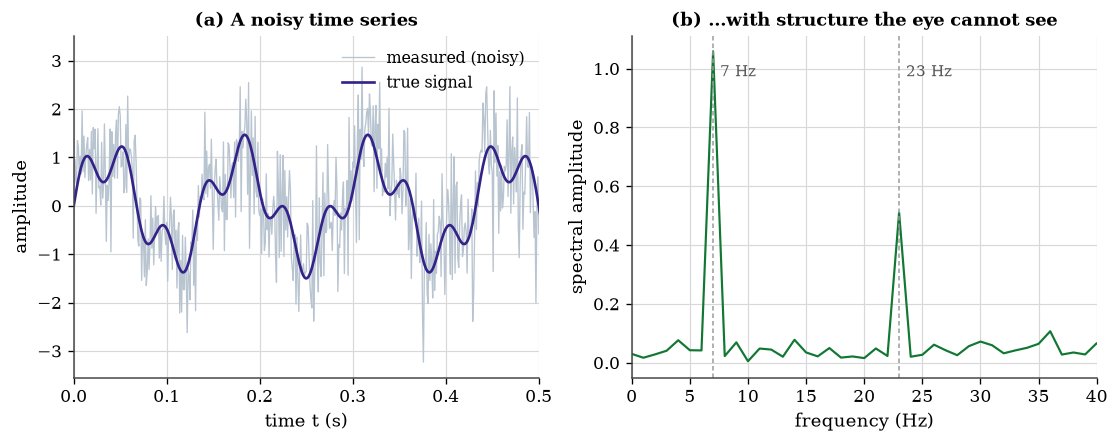

In [9]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 1.0, 1000, endpoint=False)
clean = np.sin(2 * np.pi * 7 * t) + 0.5 * np.sin(2 * np.pi * 23 * t)
noisy = clean + 0.8 * rng.standard_normal(t.size)

freqs = np.fft.rfftfreq(t.size, d=t[1] - t[0])
amp = np.abs(np.fft.rfft(noisy)) * 2 / t.size

fig, ax = plt.subplots(1, 2, figsize=(11, 3.7))
ax[0].plot(t, noisy, color="#b8c4d0", lw=0.8, label="measured (noisy)")
ax[0].plot(t, clean, color=TOL[0], lw=1.6, label="true signal")
ax[0].set(xlabel="time t (s)", ylabel="amplitude", xlim=(0, 0.5))
ax[0].legend(loc="upper right"); ax[0].set_title("(a) A noisy time series", fontsize=11)
ax[1].plot(freqs, amp, color=TOL[1], lw=1.3)
for f0 in (7, 23):
    ax[1].axvline(f0, color="#999", ls=(0, (3, 2)), lw=0.9)
    ax[1].text(f0 + 0.6, amp.max() * 0.92, f"{f0} Hz", fontsize=9, color="#555")
ax[1].set(xlabel="frequency (Hz)", ylabel="spectral amplitude", xlim=(0, 40))
ax[1].set_title("(b) ...with structure the eye cannot see", fontsize=11)
_save(fig, "demo_scipy")
peaks = np.sort(freqs[np.argsort(amp)[-2:]])
print(f"recovered dominant frequencies: {peaks[0]:.1f} Hz and {peaks[1]:.1f} Hz")

Taylor series of sin(x) to 9th order:


x**9/362880 - x**7/5040 + x**5/120 - x**3/6 + x

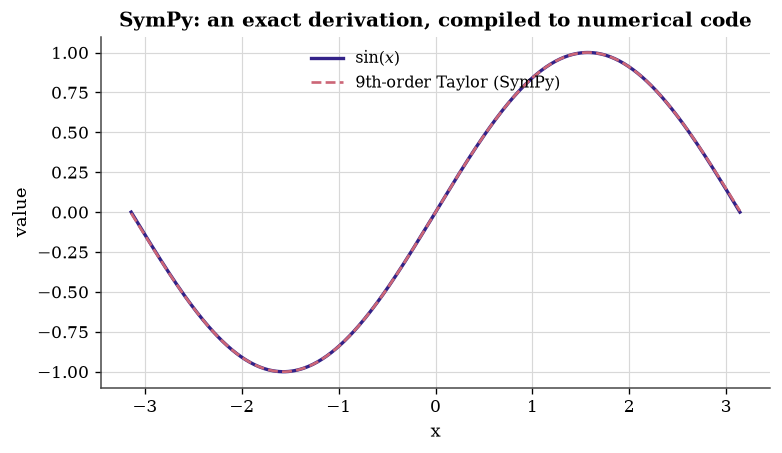

In [10]:
import numpy as np, sympy as sp
import matplotlib.pyplot as plt

from IPython.display import display

x = sp.symbols("x")
series = sp.series(sp.sin(x), x, 0, 10).removeO()      # exact 9th-order Taylor poly
print("Taylor series of sin(x) to 9th order:")
display(series)                                         # rendered as typeset math

approx = sp.lambdify(x, series, "numpy")               # exact math -> fast NumPy fn
xs = np.linspace(-np.pi, np.pi, 400)
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.plot(xs, np.sin(xs), color=TOL[0], lw=2.0, label=r"$\sin(x)$")
ax.plot(xs, approx(xs), color=TOL[2], lw=1.6, ls="--",
        label="9th-order Taylor (SymPy)")
ax.set_xlabel("x"); ax.set_ylabel("value"); ax.legend(loc="upper center")
ax.set_title("SymPy: an exact derivation, compiled to numerical code")
_save(fig, "demo_sympy")

In [12]:
import numpy as np, xarray as xr
import dask.array as da

# xarray: an array that knows what its axes mean
temps = xr.DataArray(
    rng.normal(15, 5, size=(3, 4)),
    dims=("city", "month"),
    coords={"city": ["Oslo", "Nairobi", "Lima"],
            "month": ["Mar", "Apr", "May", "Jun"]},
    name="temperature_C",
)
print("Per-city mean temperature (named-dimension reduction):")
print(temps.mean(dim="month").to_series().round(2).to_string())

# Dask: the NumPy interface, evaluated lazily and in chunks
big = da.random.random((20_000, 20_000), chunks=(2_000, 2_000))   # ~3 GB if realized
lazy_mean = big.mean()                       # nothing computed yet -> a task graph
print(f"\nDask array: {big.shape} in {big.npartitions} chunks; "
      f"graph builds instantly, mean computes to {float(lazy_mean.compute()):.4f}")

Per-city mean temperature (named-dimension reduction):
city
Oslo       17.19
Nairobi    14.04
Lima       15.68

Dask array: (20000, 20000) in 100 chunks; graph builds instantly, mean computes to 0.5000


Taken together, these libraries share two properties that recur throughout this paper: they are open source, and they agree on interfaces. The array protocol lets independently authored packages compose; the estimator and labeled-array conventions let a researcher carry intuition from one library to the next. Jupyter's contribution was to place a single, interactive, narrative surface over all of them. The interactivity is not merely a convenience for the author. Because a notebook can embed live controls, a reader can manipulate a computation directly, turning a static figure into an instrument. The widget below lets one vary a sample size and a distribution and watch an empirical histogram converge toward its theoretical density.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from ipywidgets import interact, IntSlider, Dropdown

DISTS = {"normal": stats.norm(0, 1),
         "exponential": stats.expon(scale=1.0),
         "uniform": stats.uniform(-2, 4)}

def explore(n=400, dist="normal"):
    d = DISTS[dist]
    samples = d.rvs(size=n, random_state=np.random.default_rng(SEED))
    fig, ax = plt.subplots(figsize=(7.2, 3.8))
    ax.hist(samples, bins=40, density=True, color="#cdd9e3",
            edgecolor="white", label=f"{n} samples")
    grid = np.linspace(samples.min(), samples.max(), 300)
    ax.plot(grid, d.pdf(grid), color=TOL[2], lw=2.2, label="true density")
    ax.set_title(f"Empirical vs. theoretical density  (n = {n}, {dist})")
    ax.set_xlabel("value"); ax.set_ylabel("density"); ax.legend(loc="upper right")
    plt.show()

interact(explore,
         n=IntSlider(min=20, max=5000, step=20, value=400, description="samples"),
         dist=Dropdown(options=list(DISTS), value="normal", description="distribution"));

interactive(children=(IntSlider(value=400, description='samples', max=5000, min=20, step=20), Dropdown(descrip…

**Figure 6 (interactive).** A live control over sample size and distribution. In a running kernel the sliders update the figure continuously; in a static rendering, the initial state is shown. Interactivity of this kind turns a reader into an experimenter, which is precisely why notebooks became the medium of choice for teaching, exploration, and (increasingly) publication [@perkel2018jupyter].

## Open science and reproducibility
If interactivity made notebooks the natural home for exploration, openness made them a candidate vehicle for reproducible publication. The two agendas converged in the mid-2010s. The FAIR Guiding Principles [@wilkinson2016fair] argued that scholarly outputs should be Findable, Accessible, Interoperable, and Reusable (principles later extended explicitly to research software [@barker2022fair4rs]. Practical guidance accumulated in parallel, drawing heavily on notebook pedagogy championed by educators (including Jessica Hamrick, Lorena A. Barba, Amy J. Ko, and Allen Downey) [@hamrick2016nbgrader; @barba2016computational]: the "ten simple rules" for reproducible computational research [@sandve2013ten] and the "best practices" and "good enough practices" series [@wilson2014best; @wilson2017good] (championed by open science leaders like Greg Wilson, Neil Chue Hong, Titus Brown, Daniel S. Katz, and Karthik Ram) translated the aspiration into habits (*e.g.,* version everything, automate the pipeline, record the environment.

Recording the environment proved to be the crux. A notebook captures code and narrative, but its results depend on a web of library versions and system libraries that the document itself does not pin. Two technologies addressed this gap. Containerization, popularized by Docker [@merkel2014docker], let an entire software environment be specified declaratively and rebuilt identically elsewhere. Binder, pioneered by community leaders such as Yuvi Panda, Chris Holdgraf, and Tim Head [@jupyter2018binder], connected that capability to notebooks: given only a public Git repository with its dependencies declared, the `repo2docker` tool builds a container image and JupyterHub serves a live, executable session in the browser, so that a reader can run a paper's notebooks without installing anything. For the first time, "click here to reproduce my analysis" became a realistic offer rather than a rhetorical one.

The honest assessment is that these tools made reproducibility *achievable* but not *automatic*, and each has limits worth stating plainly. Public Binder sessions are ephemeral and resource-limited, unsuited to long or data-heavy computations. Container images pin software but not always the data, the hardware, or sources of nondeterminism such as random seeds, thread counts, and floating-point reduction order. Dependency specifications drift: an environment that omits exact versions may resolve differently months later, and upstream packages disappear. Reproducibility, in short, is a property a researcher must actively engineer (*e.g.,* by pinning versions, fixing seeds (as this notebook does in its setup cell), separating data acquisition from analysis, and testing that the pipeline runs end to end. Openness lowers the cost of doing so dramatically, because open formats and open infrastructure let the community build the supporting tools; but it does not remove the responsibility. The next section quantifies how often, in practice, that responsibility goes unmet.

## The challenges of traditional notebooks
The very features that make notebooks excellent for exploration create difficulties when the same documents are asked to serve as durable, shareable software. The root cause is *hidden state*. A kernel holds a persistent namespace, and cells may be executed in any order and any number of times. The visible document records the cells and their last outputs, but not the sequence of executions that produced them. A notebook can therefore look correct on screen while depending on a variable defined in a cell that has since been deleted, or on a definition that no longer exists in the order shown (a discrepancy invisible until someone restarts the kernel and runs from the top.

The challenges of hidden state have drawn pointed criticism (most famously in Joel Grus's 2018 JupyterCon talk, 'I Don't Like Notebooks' [@grus2018idontlike]) and the empirical literature documents how widespread the consequences are. In the largest study of its kind, @pimentel2019large collected about 1.4 million Jupyter notebooks from roughly 264,000 GitHub repositories and attempted to execute the 863,878 that were valid Python with an unambiguous cell order. Only 24.1% ran to completion without raising an error, and only 4.0% reproduced the outputs stored in the document; failures were dominated by unmet dependencies (`ImportError`/`ModuleNotFoundError` accounted for about 29% of them). Symptoms of hidden state were pervasive: 36.4% of notebooks had been executed out of order, and 76.9% had at least one gap in their execution counters, indicating cells run and then removed. A follow-up that re-ran the analysis on a deduplicated corpus reached broadly similar conclusions [@pimentel2021understanding]. Figure 11 summarizes the funnel.

In [14]:
fig_repro_bars()

**Figure 7.** The reproducibility funnel from @pimentel2019large, as a share of the 863,878 valid notebooks they attempted to execute. The collapse from "runs without error" to "reproduces the stored results" measures the gap between a notebook that looks finished and one that actually is.

The problems extend beyond execution. Because `.ipynb` files are JSON documents that embed outputs (including rendered images as base64 text), they interact badly with line-oriented version control: diffs are noisy and merges conflict over machine-generated metadata, discouraging the branching-and-review workflow that underpins collaborative software. Testing and debugging are awkward when the unit of code is a cell rather than an importable function, and a long notebook tends to accumulate globals and implicit ordering that resist refactoring as the analysis grows. Qualitative studies trace these frictions to a deeper tension. @rule2018exploration, analyzing over a million notebooks alongside interviews, found a persistent conflict between *exploration* and *explanation*: notebooks accrete exploratory mess and are seldom cleaned up for sharing. Interview and survey studies catalogue the resulting pain points across the whole workflow (*e.g.,* setup, exploration, refactoring, deployment, and collaboration) [@chattopadhyay2020whats], and characterize the informal versioning and narrative practices analysts improvise in their absence [@kery2018story]. A line of tools has tried to help from within: "code gathering" to extract the minimal cells behind a result [@head2019managing], and methods to restore a reproducible execution order automatically [@wang2020better; @wang2020restoring]. These are valuable, but they treat symptoms. The structural response (*i.e.,* bringing the notebook the engineering machinery that scripts and IDEs have long enjoyed) is the subject of the next section.

## Open source IDE-native notebooks
The most important recent development in interactive scientific computing is a change in where notebooks live. This convergence of the exploratory notebook and the engineering workbench first took root with JupyterLab (architected by project leaders like Afshin Darian, Steven Silvester, and Paul Ivanov), which brought terminals, text editors, and notebooks into a single extensible interface. Today, the notebook is increasingly a first-class citizen inside a full software-development environment, sitting beside source files, a debugger, a test runner, a version-control panel, and a terminal, and benefiting from the same language intelligence as ordinary code. This is less a product category than a *movement* (a convergence of the exploratory notebook and the engineering workbench) and, like the developments before it, it was made possible by open standards.

Two protocols are central. The Language Server Protocol (LSP), opened by Microsoft in 2016 in collaboration with Red Hat and Codenvy, is a JSON-RPC standard by which an editor obtains language intelligence (*e.g.,* completion, hover documentation, go-to-definition, diagnostics, and refactorings) from a separate *language server* [@msft_lsp_spec]. Its significance is combinatorial: instead of every one of *M* editors implementing support for every one of *N* languages, each editor and each language implement the protocol once, turning an *M*×*N* problem into an *M*+*N* one. The Debug Adapter Protocol (DAP) does the same for debuggers [@msft_dap_spec]. Jupyter adopted both ideas. The Jupyter debugger protocol (JEP 47) [@jep47_debugger_protocol] wraps DAP messages inside Jupyter messages (*e.g.,* `debug_request` and `debug_reply` on the Control channel, `debug_event` on IOPub) so that a frontend can drive breakpoints and variable inspection in a running kernel; the kernel advertises support in its `kernel_info_reply`, and implementations arrived through `debugpy` in `ipykernel` and through `xeus`-based kernels (Corlay and Mabille, 2020). Because these protocols are open, a notebook hosted in any conforming environment can offer the same completion, refactoring, linting, and step-through debugging that script authors take for granted.

Open standards also reconciled notebooks with version control. Jupytext [@jupytext] represents a notebook as a plain-text script or Markdown file and keeps the two paired, so that the text form (free of outputs and volatile metadata) produces clean line diffs and reviewable pull requests, while the `.ipynb` retains rich outputs for reading. nbdime supplies content-aware diff and merge that understand notebook structure rather than raw JSON [@nbdime]. For execution and testing, papermill parameterizes and runs notebooks as pipeline stages [@papermill]; nbval [@nbval] turns a notebook into a regression test by comparing recomputed outputs against saved ones, and testbook unit-tests functions defined in notebooks directly [@testbook]; and jupyter-cache re-executes only the cells that changed [@jupyter_cache]. Perhaps the fullest expression of the convergence is nbdev [@nbdev], which treats notebooks as the source of truth for a Python package (*e.g.,* generating modules, tests, and documentation from them) and thereby realizes Knuth's literate-programming ideal four decades on [@knuth1984literate], with the fast.ai library itself built this way [@fastai_paper].

Surrounding these notebook-aware tools is the ordinary furniture of a development environment, now within reach of the cell a scientist is editing. An integrated terminal makes shell commands (*e.g.,* installing a package, inspecting a data file, launching a job) part of the same session rather than a switch to another window. Package and environment management, whether through virtual environments, conda, or lockfile-based resolvers, can be driven from the same interface that runs the notebook, so that the environment a result depends on is created and recorded where the result is produced. Linters and type checkers flag mistakes as code is typed, and the plain-text representations that jupytext maintains drop directly into continuous-integration pipelines, where nbval or papermill can execute a notebook on every commit and fail the build if a figure or a number changes unexpectedly. None of these capabilities is new to software engineering; what is new is that the scientist need not leave the exploratory document to use any of them. Figure 12 places these capabilities against earlier generations.

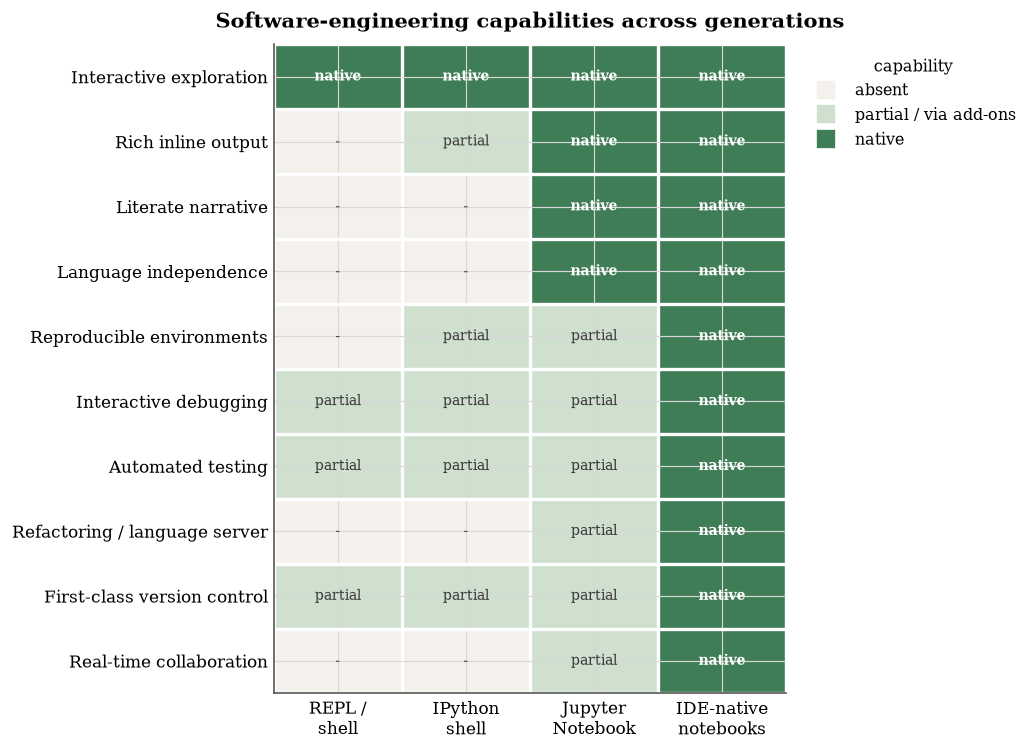

In [15]:
fig_capabilities()

**Figure 8.** A qualitative assessment by the authors of where ten software-engineering capabilities sit across four generations of interactive tools. The pattern, not any single cell, is the point: capabilities that classic notebooks could reach only through add-ons become native when the notebook is hosted inside a development environment (without sacrificing the interactive exploration of the first row.

The decisive question is whether this engineering rigor comes at the expense of the exploratory freedom that made notebooks valuable. We argue that it need not, because the integration is *additive*. A scientist still opens a cell, types an idea, and runs it; what changes is that the same idea can, without leaving the environment, be linted as it is written, extracted into a tested function, stepped through in a debugger when it misbehaves, committed with a readable diff, and packaged for reuse. The exploratory loop is preserved; the cliff that once separated a promising notebook from maintainable software is graded into a ramp. The demonstration below enacts the smallest version of this transition. We write a function to a source module (so that notebook and script literally share the same code) then import it back and test it against an analytic solution, all without leaving the document.

In [16]:
%%writefile cooling.py
# A small module written from the notebook -- source and notebook now coexist.
import numpy as np

def newton_cooling(T0, T_env, k, t):
    """Analytic solution of Newton's law of cooling: T(t)=T_env+(T0-T_env)e^{-kt}."""
    return T_env + (T0 - T_env) * np.exp(-k * np.asarray(t, dtype=float))

def euler_step(T, T_env, k, dt):
    """One explicit-Euler step of dT/dt = -k (T - T_env)."""
    return T + dt * (-k * (T - T_env))

Writing cooling.py


In [17]:
import numpy as np
from cooling import newton_cooling, euler_step      # the module we just wrote

# A lightweight in-notebook test: numerical integration must approach the
# analytic solution as the step size shrinks. This is the habit that nbval,
# testbook, and CI build upon -- testable code, defined and checked in place.
def integrate(T0, T_env, k, t_end, dt):
    T, ts, Ts = T0, [0.0], [T0]
    while ts[-1] < t_end - 1e-9:
        T = euler_step(T, T_env, k, dt); ts.append(ts[-1] + dt); Ts.append(T)
    return np.array(ts), np.array(Ts)

t_end = 5.0
errors = {}
for dt in (0.5, 0.1, 0.01):
    ts, Ts = integrate(90.0, 20.0, 0.7, t_end, dt)
    errors[dt] = np.max(np.abs(Ts - newton_cooling(90.0, 20.0, 0.7, ts)))

assert errors[0.5] > errors[0.1] > errors[0.01], "error must shrink with dt"
assert errors[0.01] < 0.5, "fine step should track the analytic solution"
print("test passed -- max error by step size:",
      {dt: round(e, 3) for dt, e in errors.items()})

test passed -- max error by step size: {0.5: np.float64(5.272), 0.1: np.float64(0.929), 0.01: np.float64(0.09)}


That cell is mundane on purpose. A function lives in a real `.py` module *and* in the running notebook; a test asserts a mathematical property and would fail loudly if the implementation regressed; and the whole exchange happened inside the exploratory document. Multiply this by language-server completion, a visual debugger, and a version-control panel, and the notebook stops being a place from which code must eventually escape to "become serious," and becomes a place where serious software can be written from the start.

## Artificial intelligence in the notebook
The emergence of large language models represents the latest shift in interactive scientific computing. Unlike earlier advances that primarily changed interfaces or execution environments, AI assistants increasingly participate directly in the process of exploration by generating code, explaining results, suggesting analyses, and helping users navigate complex software ecosystems. Early work on neural code generation (including systems such as Codex, a GPT model fine-tuned on public source code [@chen2021evaluating]) demonstrated that models could synthesize useful programs from natural language, and subsequent systems have extended these capabilities into notebook environments where they complete lines of code, draft entire cells, answer questions about datasets, and edit notebooks through natural-language interaction.

Like earlier developments in the history of interactive computing, these systems further shorten the path from an idea to executable code. At the same time, empirical studies suggest a more nuanced picture than simple productivity gains. A controlled study of an LLM-based code completion tool found that it did not consistently reduce task completion time and that programmers often invested substantial effort in understanding and verifying generated code [@vaithilingam2022expectation]. Observational work identified two distinct modes of interaction (*acceleration*, in which developers use the model to generate code they already intend to write, and *exploration*, in which the model helps discover unfamiliar approaches), each with different strengths and failure modes [@barke2023grounded]. More recently, research has begun examining how AI assistants should be designed specifically for notebooks, where code, outputs, visualizations, and narrative coexist within a single computational document [@mcnutt2023design].

For scientific computing, the opportunities must be considered alongside longstanding concerns about reproducibility, transparency, and trust. As AI systems become collaborators rather than mere autocomplete tools, they complicate the notion of *provenance*. If portions of an analysis originate from prompts, the scientific record must capture what was asked, produced, and ultimately verified by the human.

Notebooks are particularly well suited to supporting this richer notion of provenance because they already interleave narrative, code, outputs, and execution history within a single computational artifact. Previous work on automatic provenance capture in notebooks [@pimentel2015collecting; @pimentel2017noworkflow] suggests that AI generation events could likewise become part of the scientific record rather than remaining implicit. From this perspective, AI does not eliminate the need for careful scientific practice; instead, it shifts the balance of effort from writing code toward evaluating, validating, and documenting computational reasoning. As interactive scientific computing continues to evolve, openness, reproducibility, and transparent provenance become increasingly important (not despite AI, but because human accountability remains essential regardless of how code is produced).

In a world where some code is written by people and some by models, a verifiable trail of *what was computed, with what, and by whom* is the form of trust that openness uniquely enables. Human oversight remains the load-bearing element; the tooling exists to make that oversight cheap and auditable rather than to replace it.

## Future directions

The next stage of interactive scientific computing may be defined less by faster computation than by richer interaction. Over the past twenty-five years, notebooks have gradually dissolved boundaries between exploration, documentation, publication, and software development. The next decade is likely to dissolve another boundary: the distinction between computational artifacts and interactive applications.

Notebook environments are evolving beyond static computational documents. Reactive execution models, richer user interface components, and browser-native runtimes allow notebooks to become scientific applications that users can interact with directly rather than merely execute. Instead of asking readers to modify source code, authors can increasingly expose parameters through forms, sliders, tables, and visual controls that invite exploration without requiring programming expertise. In this sense, notebooks are becoming environments not only for writing analyses but also for communicating and sharing them with broader audiences.

Whether this future benefits science will depend, once again, on openness. Interactive documents, reactive notebook systems, browser-based execution, and AI-assisted workflows all depend on open document formats, open protocols, interoperable runtimes, and transparent governance. The history traced throughout this paper repeatedly demonstrates that the greatest advances in interactive scientific computing have emerged not from proprietary lock-in but from communities that chose openness at critical moments. Preserving that tradition offers the strongest foundation for the next generation of interactive scientific computing.

## Conclusion

The history of interactive scientific computing is the history of reducing friction across four fundamental activities: exploratory analysis, software engineering, collaboration, and reproducible publication. As we have seen, each generation of tools inherited the strengths of its predecessors while internalizing capabilities that previously required separate, disjoint environments. The transition from REPLs to the IPython shell brought rich exploration and the foundations of a scientific ecosystem. Project Jupyter decoupled the interface from the runtime, creating a language-agnostic protocol that made the notebook a universal medium for literate narrative and reproducible environments. Most recently, the embedding of notebooks within IDEs has restored the rigorous software engineering practices (*e.g.,* debugging, testing, and version control) that early notebooks struggled to support.

Throughout this evolution, openness has been the decisive mechanism. Open source code, open community governance, and (crucially) open standards like the Jupyter messaging protocol and the `nbformat` schema [@jupyter-nbformat] were the enablers that allowed these tools to scale from individual scripts to a ubiquitous scientific infrastructure. As the community continues to integrate new paradigms, such as AI-assisted code generation and reactive publishing, maintaining this commitment to transparent, reproducible, and open scientific computing remains as essential as ever.

## Acknowledgements

This paper stands on the work of the IPython and Project Jupyter contributors, the maintainers of the scientific Python ecosystem, and the researchers whose empirical studies of notebooks are cited throughout. The factual claims herein were checked against primary sources during preparation; any remaining errors are the author's own.